## 추론통계와 기술통계의 차이점
#### 추론통계 : 표본을 토대로 모집단을 추출
#### 기술통계 : 가지고 있는 데이터를 요약-정리

## 모수와 통계량을 기호와 함께 구분 가능
#### 

# [LAB-07] 1. 추론통계 개요

## #01. 준비작업

### 1. 패키지 설치

- `scipy` 패키지의 설치가 필요하다.

In [3]:
!pip install --upgrade scipy


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 2. 라이브러리 참조

In [1]:
from jussam import load_data
from helper import *
from math import sqrt       # 루트 처리 함수
from scipy.stats import t   # t분포 객체

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 3. 데이터 가져오기

In [2]:
origin = load_data('height')
origin.head()

📚 어느 학교의 학년, 성별, 키에 대한 가상의 조사 자료 (출처: 방송통신대학교 통계학개론)


,학년,성별,키
0,1,남자,163
1,2,여자,154
2,1,남자,171
3,3,여자,160
4,4,남자,169


## #02. 신뢰구간 구하기

### 1. 신뢰구간을 계산할 데이터

In [3]:
data = origin['키']
data.head()

0    163
1    154
2    171
3    160
4    169
Name: 키, dtype: int64

### 2. 신뢰수준 정의

In [4]:
clevel = 0.95

### 3. 샘플 사이즈

In [5]:
n = len(data)
n

36

### 4. 자유도 (Degree of Freedom)

In [6]:
dof = n - 1
dof

35

### 5. 표본평균

In [7]:
sample_mean = data.mean()
sample_mean

np.float64(167.83333333333334)

### 6. 표본표준편차

In [8]:
sample_std = data.std()
sample_std

np.float64(7.315345905306578)

### 7. 표본표준오차

${표준편차 \over \sqrt{샘플크기}}$

In [9]:
sample_std_error = sample_std / sqrt(n)
sample_std_error

np.float64(1.2192243175510964)

### 8. 신뢰구간

`scipy.stats` 패키지의 `t` 객체가 포함하는 `interval(신뢰도, 자유도, loc=포본평균, scale=표본표준오차)` 메서드를 사용한다.

In [10]:
cmin, cmax = t.interval(clevel, dof, loc=sample_mean, 
                        scale=sample_std_error)
cmin, cmax

(np.float64(165.35817637995726), np.float64(170.30849028670943))

## #03. 모듈 기능 확인

### 1. 연속형 데이터를 전달하는 형식

- 유의수준(clevel)은 생략시 `0.95`로 지정된다.

In [16]:
print(my_stats.ci(data))
print(my_stats.ci(data, clevel=0.95))

(np.float64(165.35817637995726), np.float64(170.30849028670943))
(np.float64(165.35817637995726), np.float64(170.30849028670943))


### 2. 데이터프레임과 컬럼을 지정하는 형식

In [17]:
my_stats.ci(origin, column='키', clevel=0.95)

(np.float64(165.35817637995726), np.float64(170.30849028670943))

## #04. 신뢰구간 범위 시각화

### 1. 신뢰구간 직접 시각화하기

- KDE Plot에 신뢰구간을 세로 직선으로 추가한다.

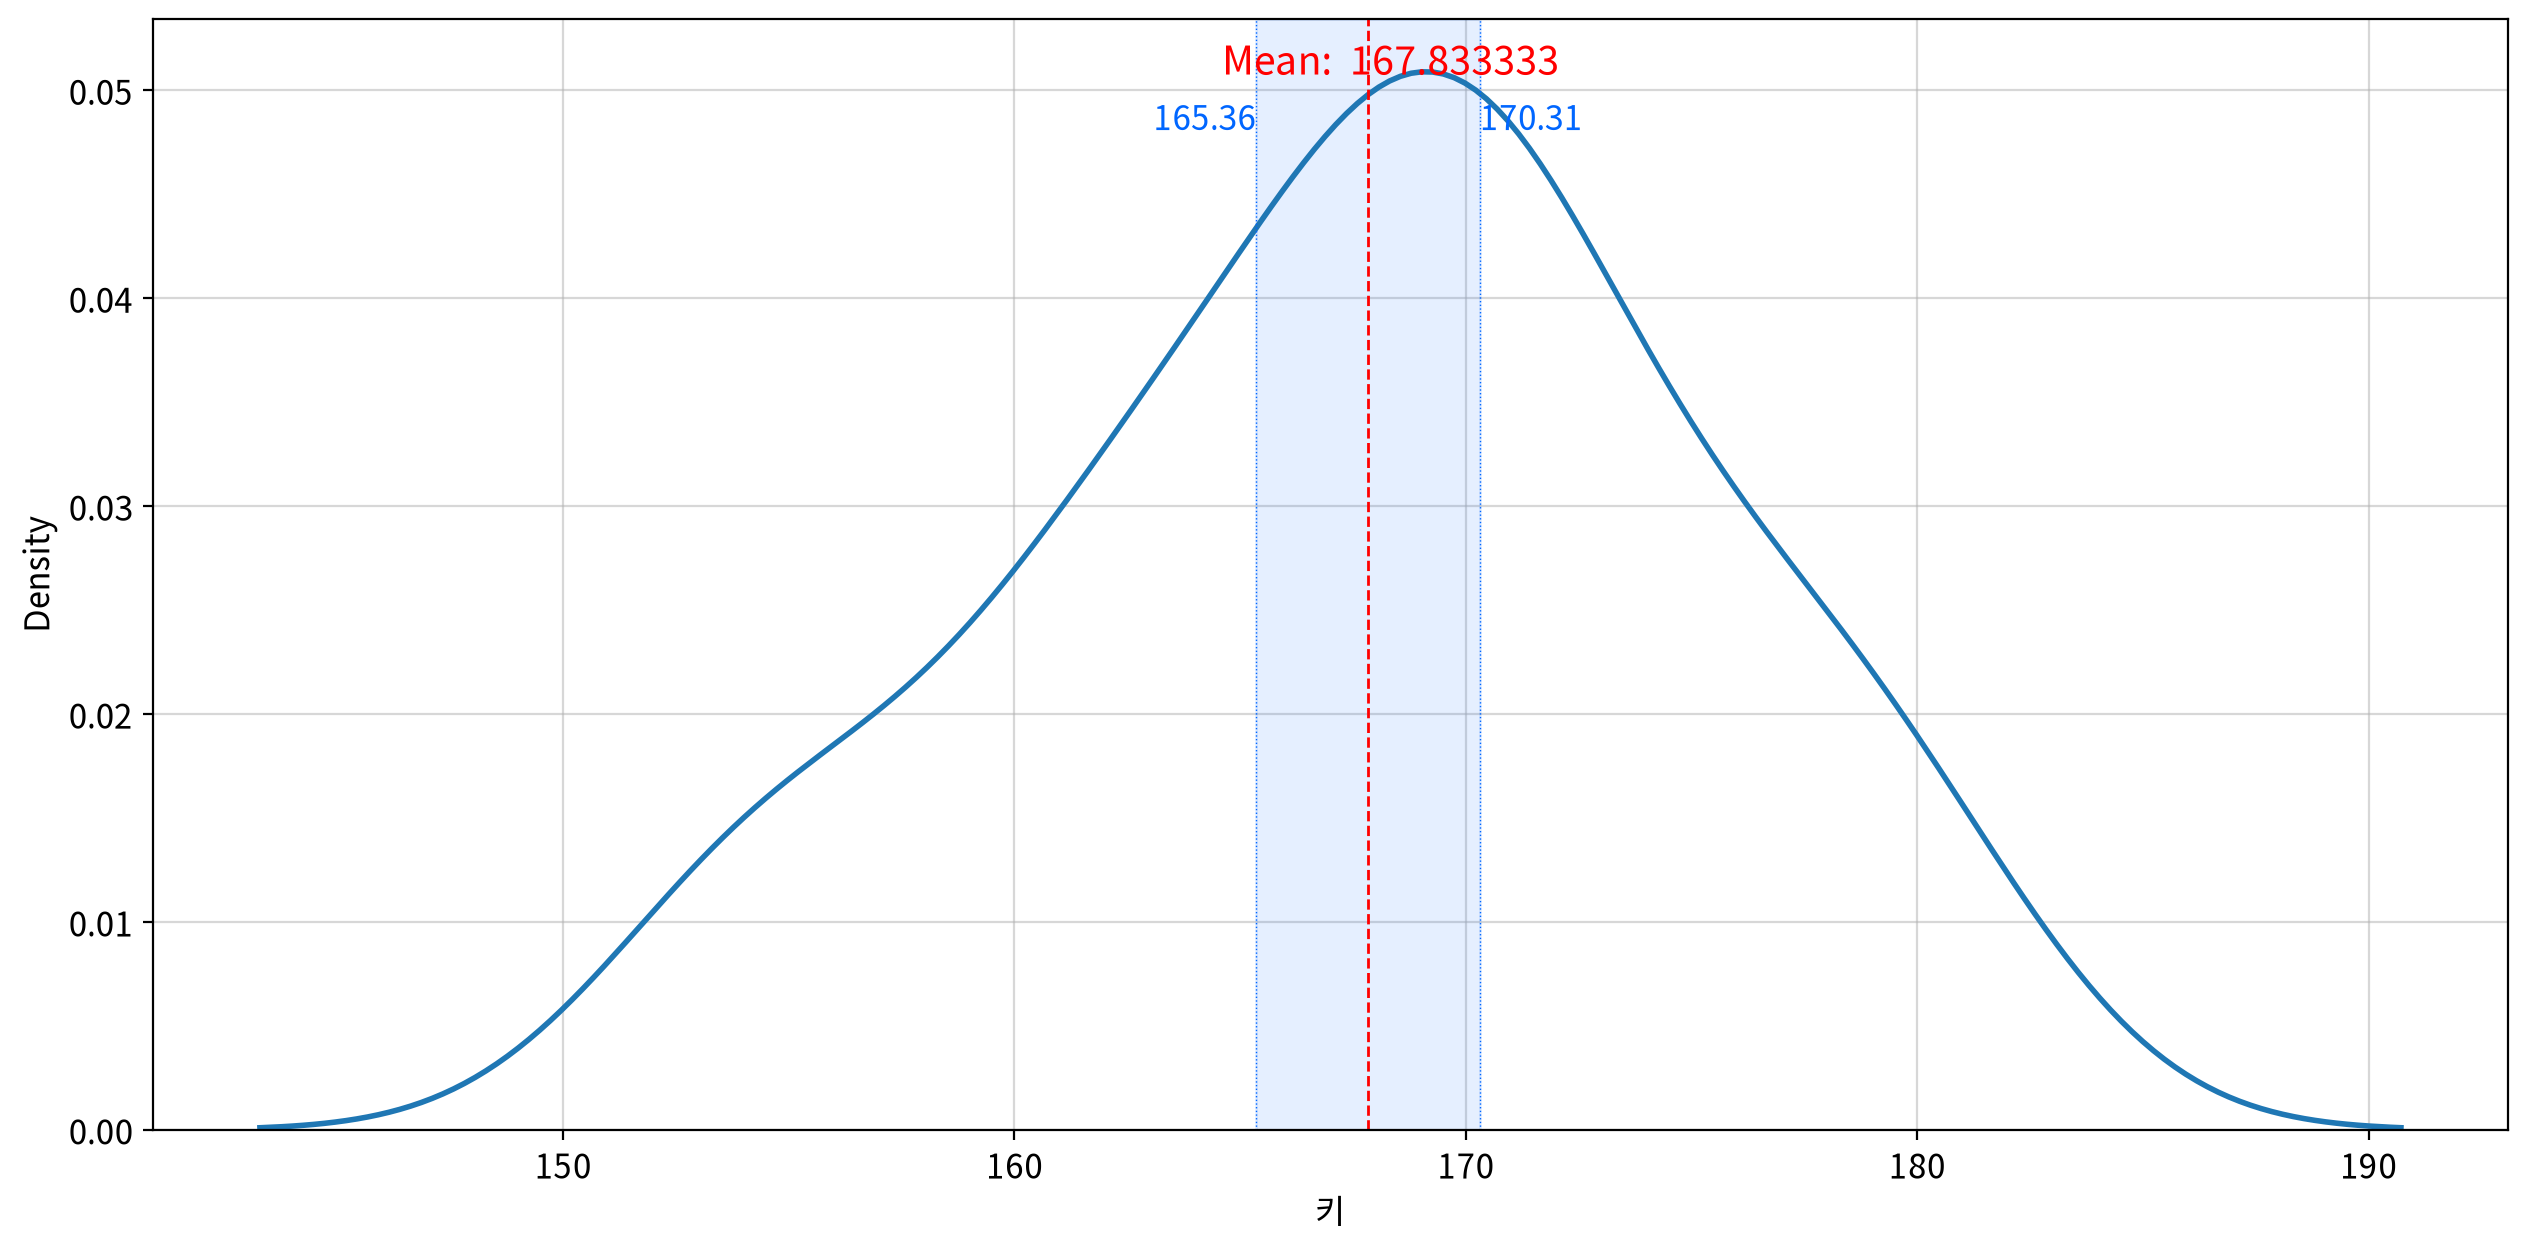

In [21]:
# ax객체를 사용하여 추가적인 그래프 요소를 그릴 수 있도록 직접 초기화
fig, ax = my_plot.init()

# KDE 플롯 그리기 (평균선 포함)
my_plot.kdeplot(data=origin, x='키', meanline=True, ax=ax)

# 신뢰구간 계산
cmin, cmax = my_stats.ci(origin, column='키', clevel=0.95)

# 신뢰구간 범위에 대한 세로 직선 그리기 (cmin ~ cmax)
ax.axvline(cmin, linestyle=':', color='#0066ff', linewidth=0.5)
ax.axvline(cmax, linestyle=':', color='#0066ff', linewidth=0.5)

# 신뢰구간 범위에 대한 텍스트 추가
ax.text(cmin, ax.get_ylim()[1]*0.9, f'{cmin:.2f}', color='#0066ff', ha='right')
ax.text(cmax, ax.get_ylim()[1]*0.9, f'{cmax:.2f}', color='#0066ff', ha='left')

ymin, ymax = ax.get_ylim()    # 현재 축 범위 가져오기
ax.set_ylim(ymin, ymax)    # y축 범위 설정 (0부터 ymax까지)

# 신뢰구간 범위에 대한 영역 채우기 (cmin ~ cmax)
ax.fill_between([cmin, cmax], 0, ymax, alpha=0.1, color='#0066ff')

my_plot.show()

## #05. 시각화 모듈 기능 확인

### 1. 단일 데이터에 대한 신뢰구간 확인

In [22]:
my_plot.kdeplot(origin, '키', meanline=True, clevel=0.95)

TypeError: kdeplot() got an unexpected keyword argument 'clevel'

### 2. 범주별 신뢰구간 확인

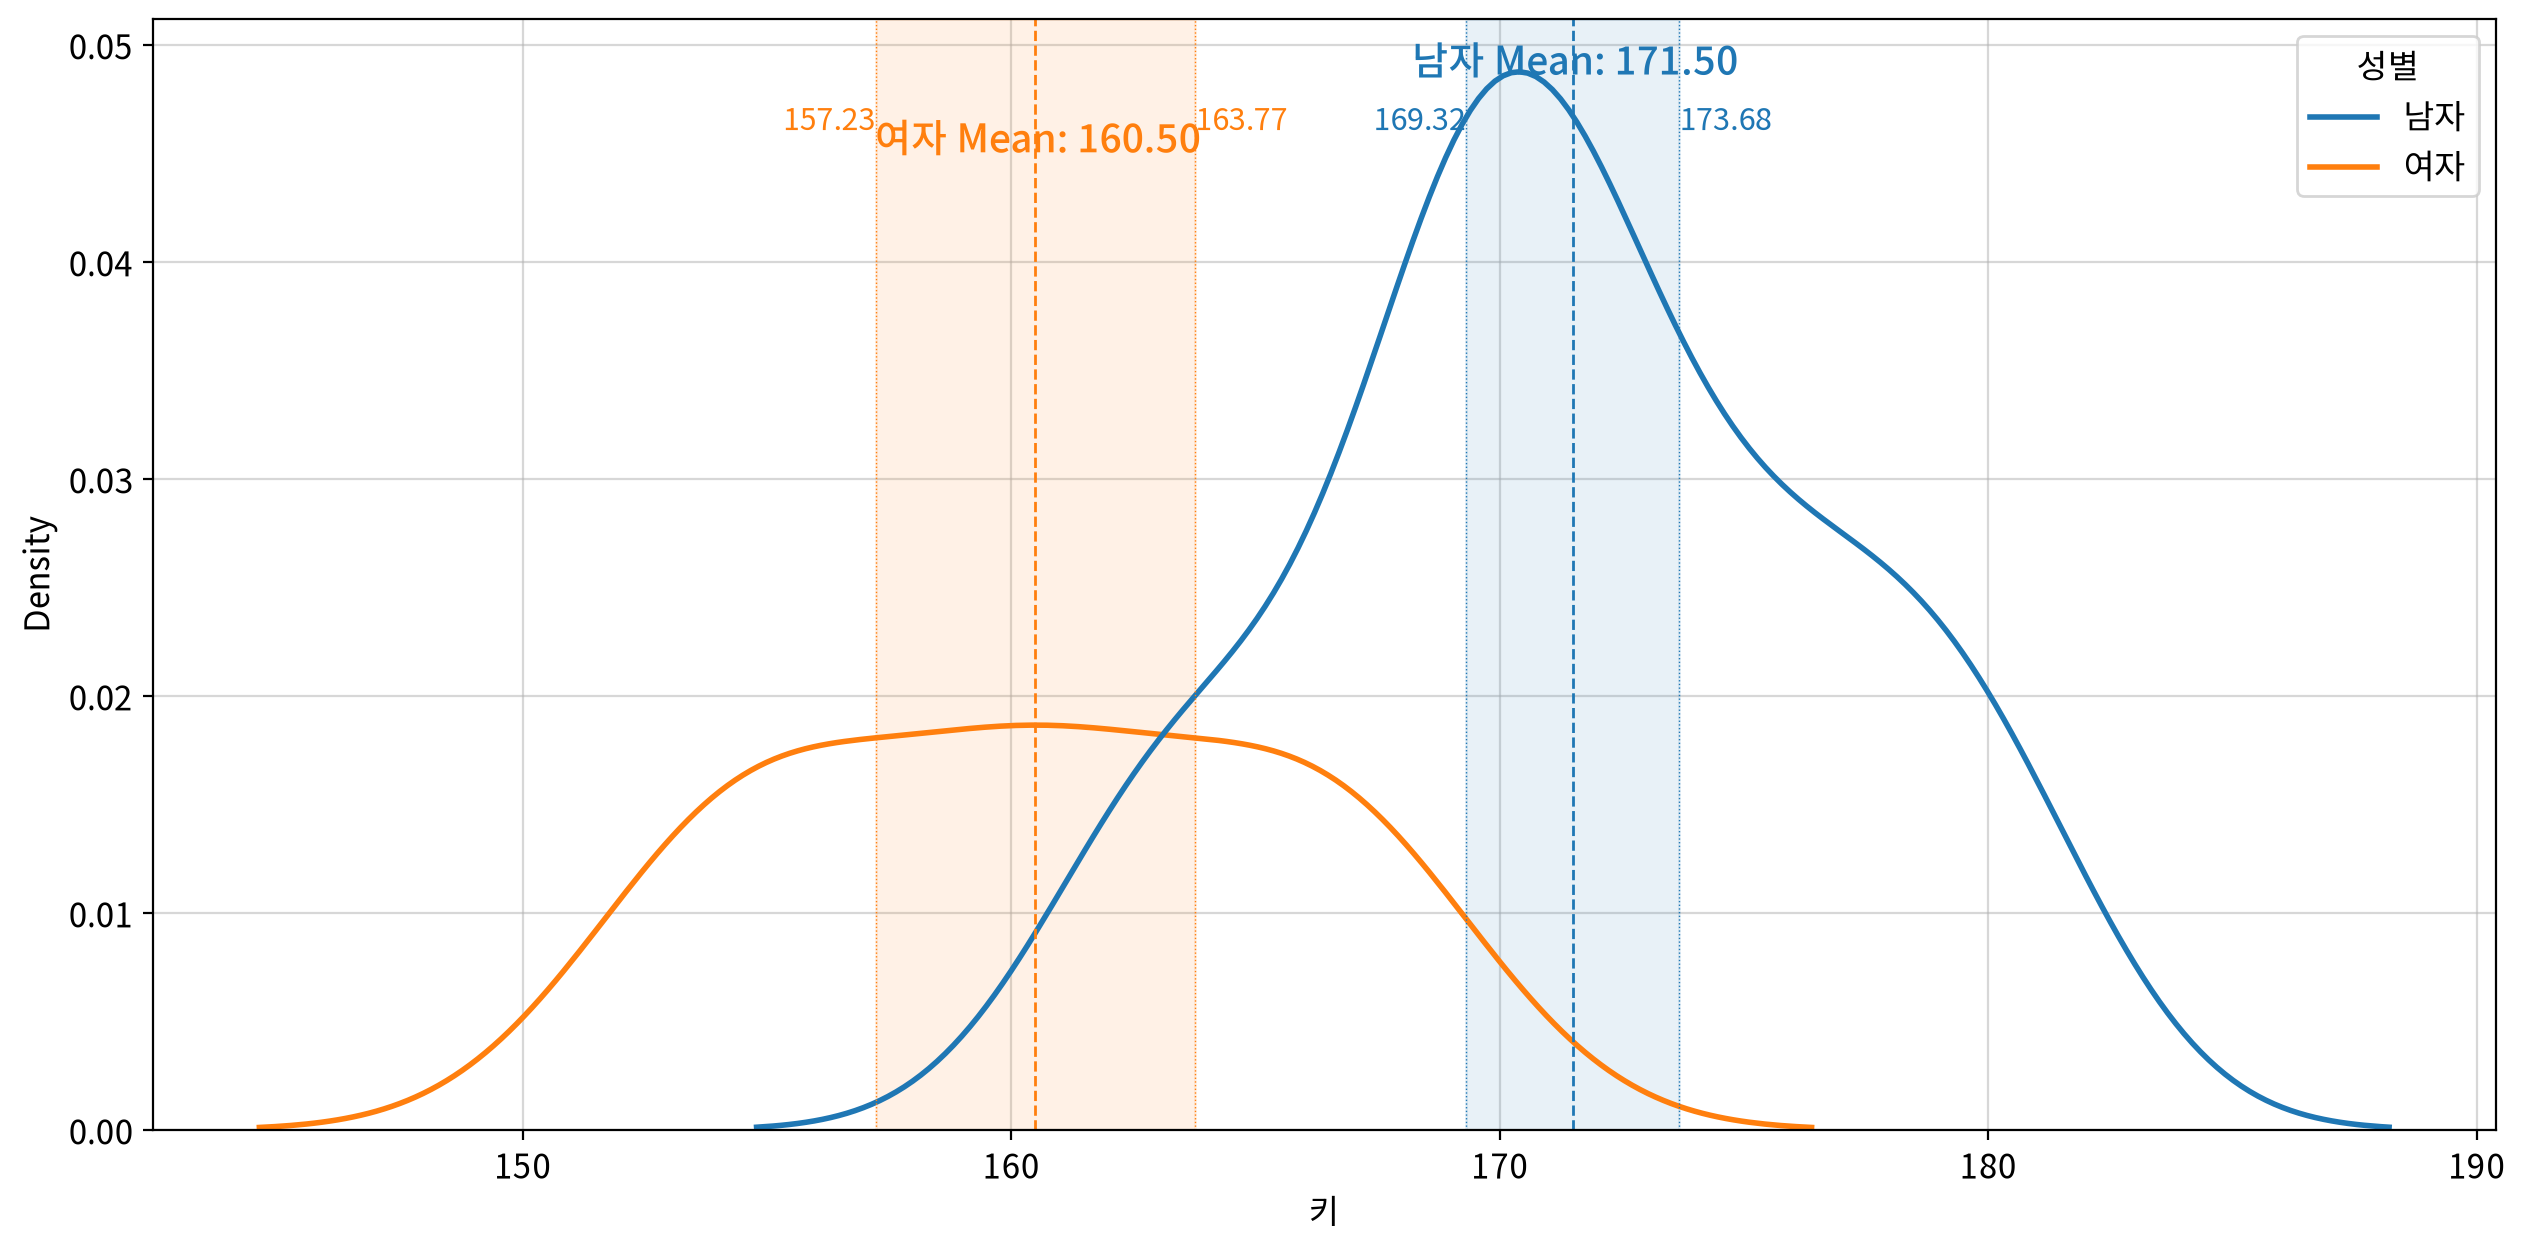

In [16]:
my_plot.kdeplot(origin, '키', hue='성별', meanline=True, clevel=0.95)